# Hệ thống định giá và phân tích thị trường xe ô tô cũ tại Việt Nam

DAP391m - Lớp AI2013 - Nhóm 2 - GVHD: Bùi Thị Loan

| Thành viên | MSSV | Phụ trách |
|---|---|---|
| Nguyễn Huy Sơn | HE191357 | Notebook 00, 04, 06: tổng quan, phân tích văn bản, phát hiện Deal |
| Đỗ Khánh Duy | HE200151 | Notebook 01, 05: thu thập dữ liệu, mô hình định giá |
| Quách Thiện Nhân | HE210429 | Notebook 02, 03: làm sạch dữ liệu, phân tích trực quan |

Báo cáo của nhóm được viết trực tiếp trong các notebook, mỗi notebook gồm code và phần giải thích cho từng bước. Notebook này là phần mở đầu: trình bày vấn đề, mục tiêu, dữ liệu và thứ tự đọc các notebook. Kết luận chung của dự án sẽ được viết ở cuối notebook này.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# tìm thư mục gốc của project để chạy được trên máy của cả nhóm
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

raw = pd.read_csv(ROOT / "data" / "raw" / "cars.csv", low_memory=False)

# tạo bản sao để phân tích, đổi giá sang triệu đồng cho dễ đọc
cars = raw.copy()
cars["price_million"] = cars["price"] / 1_000_000

## 1. Vấn đề

Thị trường xe ô tô cũ Việt Nam tồn tại bất cân xứng thông tin nghiêm trọng: người bán nắm rõ lịch sử sử dụng và tình trạng thực tế của xe, còn người mua chỉ biết những gì người bán công bố. Các sàn rao vặt chỉ đóng vai trò nơi đăng tin, không thẩm định giá, nên cùng một dòng xe và năm sản xuất có thể chênh nhau hàng trăm triệu mà người mua không có căn cứ khách quan nào để đánh giá.

Nhóm kiểm tra lại nhận định này trên dữ liệu đã thu thập. Các tin được gom thành từng nhóm xe có cùng hãng, dòng xe và năm sản xuất, chỉ giữ những nhóm có từ 20 tin trở lên. Trong mỗi nhóm xe, nhóm so giá ở mức P10 và P90 thay vì giá thấp nhất và cao nhất, vì dữ liệu gốc vẫn còn một số tin giá ảo (giá 0 đồng, tin cho thuê xe...) sẽ làm khoảng chênh bị phóng đại.

In [2]:
# gom các tin cùng hãng + dòng xe + năm sản xuất
nhom = ["carbrand_name", "carmodel_name", "mfdate"]

gia_nhom = cars.groupby(nhom)["price_million"].agg(
    so_tin="count",
    p10=lambda x: x.quantile(0.1),
    trung_vi="median",
    p90=lambda x: x.quantile(0.9),
)

# chỉ lấy nhóm có từ 20 tin trở lên cho đủ tin cậy
gia_nhom = gia_nhom[gia_nhom["so_tin"] >= 20].copy()
gia_nhom["chenh_lech"] = gia_nhom["p90"] - gia_nhom["p10"]

ti_le_chenh = (gia_nhom["chenh_lech"] / gia_nhom["trung_vi"]).median()

print(f"Số nhóm xe có từ 20 tin: {len(gia_nhom)} (tổng {gia_nhom['so_tin'].sum()} tin)")
print(f"Chênh lệch P10-P90, lấy trung vị: {gia_nhom['chenh_lech'].median():.0f} triệu, khoảng {ti_le_chenh:.0%} giá xe")
print(f"Số nhóm xe chênh từ 100 triệu trở lên: {(gia_nhom['chenh_lech'] >= 100).sum()}")

Số nhóm xe có từ 20 tin: 201 (tổng 6852 tin)
Chênh lệch P10-P90, lấy trung vị: 108 triệu, khoảng 24% giá xe
Số nhóm xe chênh từ 100 triệu trở lên: 117


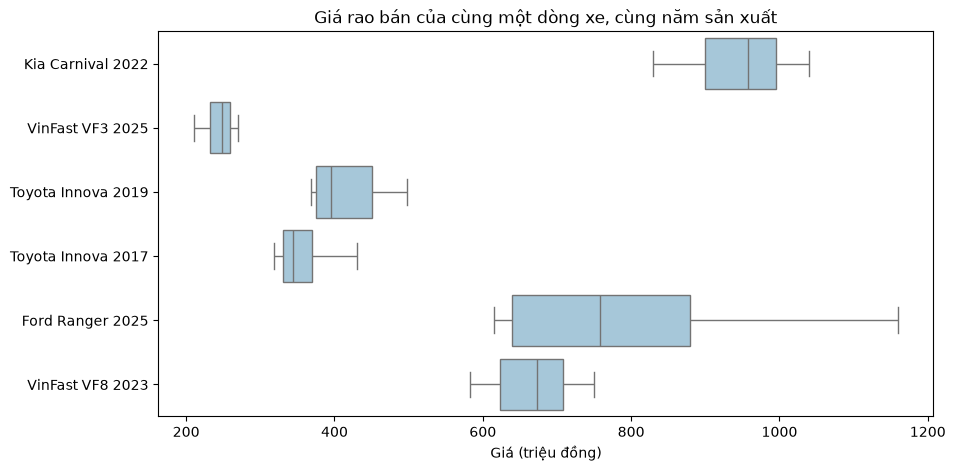

In [3]:
# vẽ 6 nhóm xe có nhiều tin nhất cho dễ nhìn
top6 = gia_nhom.nlargest(6, "so_tin").reset_index()
ten_nhom = top6["carbrand_name"] + " " + top6["carmodel_name"] + " " + top6["mfdate"].astype(str)

ve = cars.merge(top6[nhom], on=nhom)
ve["nhom_xe"] = ve["carbrand_name"] + " " + ve["carmodel_name"] + " " + ve["mfdate"].astype(str)

plt.figure(figsize=(10, 5))
# râu của hộp kéo từ P10 đến P90, không vẽ điểm ngoại lai
sns.boxplot(data=ve, x="price_million", y="nhom_xe", order=ten_nhom,
            whis=(10, 90), showfliers=False, color="#9ecae1")
plt.title("Giá rao bán của cùng một dòng xe, cùng năm sản xuất")
plt.xlabel("Giá (triệu đồng)")
plt.ylabel("")
plt.show()

Kết quả cho thấy nhận định trong proposal là đúng: với 201 nhóm xe đủ số tin, khoảng chênh giữa P10 và P90 có trung vị khoảng 108 triệu đồng (khoảng 24% giá xe), và 117 nhóm chênh từ 100 triệu trở lên. Trên biểu đồ, Ford Ranger 2025 là nhóm có giá dàn trải rộng nhất.

Tuy vậy không phải khoảng chênh nào cũng do người bán hét giá. Cùng tên dòng xe nhưng có thể khác phiên bản, khác số km hay tình trạng xe. Thử tách nhóm Ford Ranger 2025 theo tiêu đề có chữ "Raptor" hay không:

In [4]:
ranger = cars[(cars["carbrand_name"] == "Ford") & (cars["carmodel_name"] == "Ranger") & (cars["mfdate"] == 2025)]
la_raptor = ranger["subject"].str.contains("raptor", case=False)

bang = ranger.groupby(la_raptor)["price_million"].agg(["count", "median"])
bang.index = bang.index.map({True: "Raptor", False: "Bản thường"}).rename("Phiên bản")
bang.columns = ["Số tin", "Giá trung vị (triệu)"]
bang

,Số tin,Giá trung vị (triệu)
Phiên bản,,
Bản thường,62,650.0
Raptor,14,1190.0


Bản Raptor có giá trung vị gần gấp đôi bản thường nhưng trong dữ liệu vẫn chung một dòng xe "Ranger". Nếu chỉ nhìn giá, người mua không biết tin nào đắt vì xe tốt hơn, tin nào đắt vì người bán hét giá. Đây là chỗ dự án cần giải quyết: mô hình định giá (notebook 05) ước lượng giá hợp lý từ thông số của xe, sau đó notebook 06 so giá niêm yết với giá này để phát hiện Deal.

## 2. Mục tiêu

Dự án có 2 mục tiêu chính:

1. **Thẩm định giá độc lập:** xây dựng mô hình hồi quy ước lượng giá thị trường hợp lý của xe từ thông số kỹ thuật, tuổi xe và độ hao mòn (notebook 05).
2. **Phát hiện Deal:** so giá niêm yết với giá mô hình dự đoán để chia tin đăng thành 3 loại: *Deal hời / Rẻ bất thường*, *Giá hợp lý* và *Hét giá cao* (notebook 06).

Theo proposal, dự án đạt yêu cầu khi mô hình có R² > 0,85 trên tập kiểm tra, bản đồ nhiệt và Word Cloud chạy được, và khi nhập thông số của một chiếc xe thì trả ra được kết quả định giá (kịch bản đầu-cuối).

## 3. Dữ liệu

Dữ liệu được thu thập từ API công khai của Chợ Tốt bắt đầu từ ngày 14/09/2026, gồm các tin rao bán ô tô đã qua sử dụng trên toàn quốc. Nhóm chọn Chợ Tốt thay cho Bonbanh vì API trả về JSON đã có cấu trúc sẵn, ổn định hơn so với việc đọc HTML. Các con số dưới đây được tính trực tiếp từ dữ liệu.

In [5]:
mo_ta = pd.read_csv(ROOT / "data" / "raw" / "descriptions.csv")
sach = pd.read_csv(ROOT / "data" / "processed" / "cars_cleaned.csv", low_memory=False)

ngay_dang = pd.to_datetime(raw["list_time"], unit="ms")
ti_le_tinh = raw["region_name"].value_counts(normalize=True)

pd.Series({
    "Số tin đăng": len(raw),
    "Số trường dữ liệu": raw.shape[1],
    "Số mã tin bị trùng": raw["list_id"].duplicated().sum(),
    "Số tỉnh/thành": raw["region_name"].nunique(),
    "Số hãng xe": raw["carbrand_name"].nunique(),
    "Số dòng xe": raw["carmodel_name"].nunique(),
    "Ngày thu thập": pd.to_datetime(raw["fetched_at"], utc=True).min().strftime("%d/%m/%Y"),
    "Tin được đăng trong khoảng": f"{ngay_dang.min():%d/%m/%Y} - {ngay_dang.max():%d/%m/%Y}",
    "Tỷ lệ tin ở TP.HCM": f"{ti_le_tinh['Tp Hồ Chí Minh']:.0%}",
    "Tỷ lệ tin ở Hà Nội": f"{ti_le_tinh['Hà Nội']:.0%}",
    "Số tin có mô tả dài (cào bổ sung)": f"{len(mo_ta)} ({len(mo_ta) / len(raw):.0%})",
    "Số tin sau làm sạch (notebook 02)": len(sach),
}).to_frame("Giá trị")

,Giá trị
Số tin đăng,15000
Số trường dữ liệu,35
Số mã tin bị trùng,0
Số tỉnh/thành,63
Số hãng xe,58
Số dòng xe,422
Ngày thu thập,14/09/2026
Tin được đăng trong khoảng,16/07/2026 - 14/09/2026
Tỷ lệ tin ở TP.HCM,46%
Tỷ lệ tin ở Hà Nội,18%


Một số điểm cần lưu ý về dữ liệu:

- Dữ liệu lệch nhiều về TP.HCM và Hà Nội (gần 2/3 số tin), nhiều tỉnh chỉ có vài tin. Vì vậy bản đồ nhiệt ở notebook 03 dùng thang log và đánh dấu riêng các tỉnh có dưới 10 tin.
- Dữ liệu gốc chỉ có tiêu đề tin, không có phần mô tả chi tiết. Phần mô tả được cào bổ sung theo `list_id` ở notebook 01, lấy được khoảng 70% số tin, số còn lại đã bị gỡ khỏi Chợ Tốt ở thời điểm cào bổ sung. Notebook 04 dùng phần mô tả này để vẽ Word Cloud và tạo các biến cờ, tin nào không có mô tả thì dùng tiêu đề.
- Giá trong dữ liệu là giá người bán rao, chưa chắc là giá bán thực tế. Vì vậy "giá hợp lý" trong dự án được hiểu là mức giá phổ biến trên thị trường rao bán.

## 4. Thứ tự đọc các notebook

| Notebook | Nội dung | Người làm |
|---|---|---|
| [01 - Thu thập dữ liệu](../01_crawler_and_ml/01_thu_thap_du_lieu.ipynb) | Crawler API Chợ Tốt, mô tả 35 trường dữ liệu, cào bổ sung mô tả | Đỗ Khánh Duy |
| [02 - Làm sạch dữ liệu](../02_analytics_and_dashboard/02_lam_sach_du_lieu.ipynb) | Chuẩn hóa giá, ODO, tỉnh/thành; loại tin rác và ngoại lai; giải mã các cột dạng mã số | Quách Thiện Nhân |
| 03 - Phân tích trực quan: [EDA](../02_analytics_and_dashboard/03_phan_tich_truc_quan.ipynb), [bản đồ nhiệt](../02_analytics_and_dashboard/choropleth_map/ban_do_nhiet.ipynb), [dashboard](../02_analytics_and_dashboard/dashboard.ipynb) | Phân phối giá, khấu hao theo năm và ODO, giá theo tỉnh, bộ lọc tương tác | Quách Thiện Nhân |
| [04 - Phân tích văn bản](04_phan_tich_van_ban.ipynb) | Word Cloud, biến cờ từ mô tả tin | Nguyễn Huy Sơn |
| [05 - Mô hình định giá](../01_crawler_and_ml/05_mo_hinh_dinh_gia.ipynb) | Huấn luyện, so sánh và đánh giá mô hình | Đỗ Khánh Duy |
| [06 - Phát hiện Deal](06_phat_hien_deal.ipynb) | Phân loại 3 nhãn Deal, định giá một chiếc xe | Nguyễn Huy Sơn |

Dữ liệu đi qua các notebook như sau:

- `data/raw/cars.csv` -> 02 -> `data/processed/cars_cleaned.csv` -> 03, 04, 05, 06
- 01 -> `data/raw/descriptions.csv` -> 04 -> `data/processed/text_flags.csv` -> 05
- 05 -> `models/car_pricing_model.pkl` -> 06

## 5. Kết quả và kết luận

*Phần này sẽ được viết sau khi hoàn thành mô hình định giá (notebook 05) và phát hiện Deal (notebook 06).*